In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf 
from tensorflow.keras import layers , models , callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os 
os.makedirs('models',exist_ok = True)


In [3]:
EDGE_TYPES = {
    0:'Horizontal', 1:'Vertical', 2:'Diagonal BL-TR', 3:'Diagonal TL-BR',
    4:'Corner TL', 5:'Corner TR', 6:'Corner BL', 7:'Corner BR',
    8:'T-Top', 9:'T-Bottom', 10:'Cross', 11:'No Edge'
}
NUM_CLASSES = 12
x= np.load('X_synthetic.npy')
y= np.load('y_synthetic.npy')


In [4]:
from pandas.core.common import random_state
x_trainval , x_test,  y_trainval , y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

x_train ,x_val , y_train, y_val = train_test_split(x_trainval,y_trainval,test_size=0.15,stratify=y_trainval,random_state=42)

In [5]:
from tensorflow.keras import layers
def build_cnn(input_shape=(5, 5, 1), num_classes=12):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.35),
        layers.Dense(num_classes, activation='softmax')
    ], name='EdgeCNN_v1')
    return model

model = build_cnn()
model.summary()

Model: "EdgeCNN_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,676 (881.55 KB)

 Trainable params: 225,484 (880.80 KB)

 Non-trainable params: 192 (768.00 B)

In [6]:
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
checkpoint = callbacks.ModelCheckpoint(
    'models/edge_cnn_v1_best.keras', monitor='val_accuracy',
    save_best_only=True, verbose=1
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/50
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9062 - loss: 0.3267
Epoch 1: val_accuracy improved from None to 0.08333, saving model to models/edge_cnn_v1_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9594 - loss: 0.1411 - val_accuracy: 0.0833 - val_loss: 3.0590 - learning_rate: 0.0010
Epoch 2/50
125/128 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9801 - loss: 0.0679
Epoch 2: val_accuracy did not improve from 0.08333
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9811 - loss: 0.0636 - val_accuracy: 0.0833 - val_loss: 2.9106 - learning_rate: 0.0010
Epoch 3/50
122/128 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9831 - loss: 0.0559
Epoch 3: val_accuracy improved from 0.08333 to 0.73056, saving model to models/edge_cnn_v1_best.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9831 - loss: 0.0554 - val_accuracy: 0.7306 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 4/50
125/128 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 

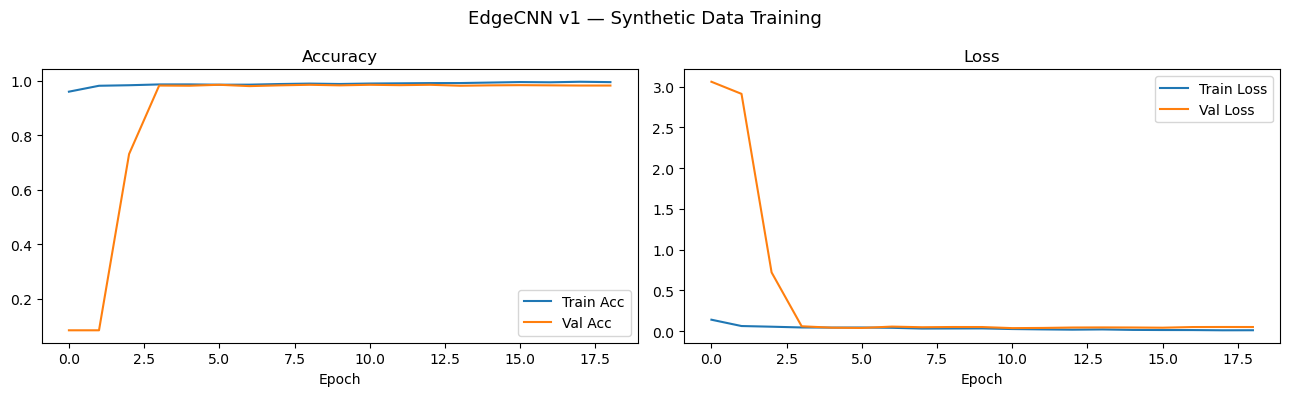

In [8]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],     label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.suptitle('EdgeCNN v1 — Synthetic Data Training', fontsize=13)
plt.tight_layout()
plt.savefig('images/training_curves_v1.png', dpi=120)
plt.show()

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=list(EDGE_TYPES.values())))

Test Accuracy : 98.62%
Test Loss     : 0.0391

Classification Report:
                precision    recall  f1-score   support

    Horizontal       0.97      0.99      0.98       200
      Vertical       0.99      0.99      0.99       200
Diagonal BL-TR       1.00      1.00      1.00       200
Diagonal TL-BR       1.00      1.00      1.00       200
     Corner TL       1.00      0.98      0.99       200
     Corner TR       0.97      0.99      0.98       200
     Corner BL       0.99      0.99      0.99       200
     Corner BR       0.99      0.99      0.99       200
         T-Top       0.97      0.96      0.97       200
      T-Bottom       0.98      0.94      0.96       200
         Cross       0.97      0.99      0.98       200
       No Edge       0.99      0.99      0.99       200

      accuracy                           0.99      2400
     macro avg       0.99      0.99      0.99      2400
  weighted avg       0.99      0.99      0.99      2400



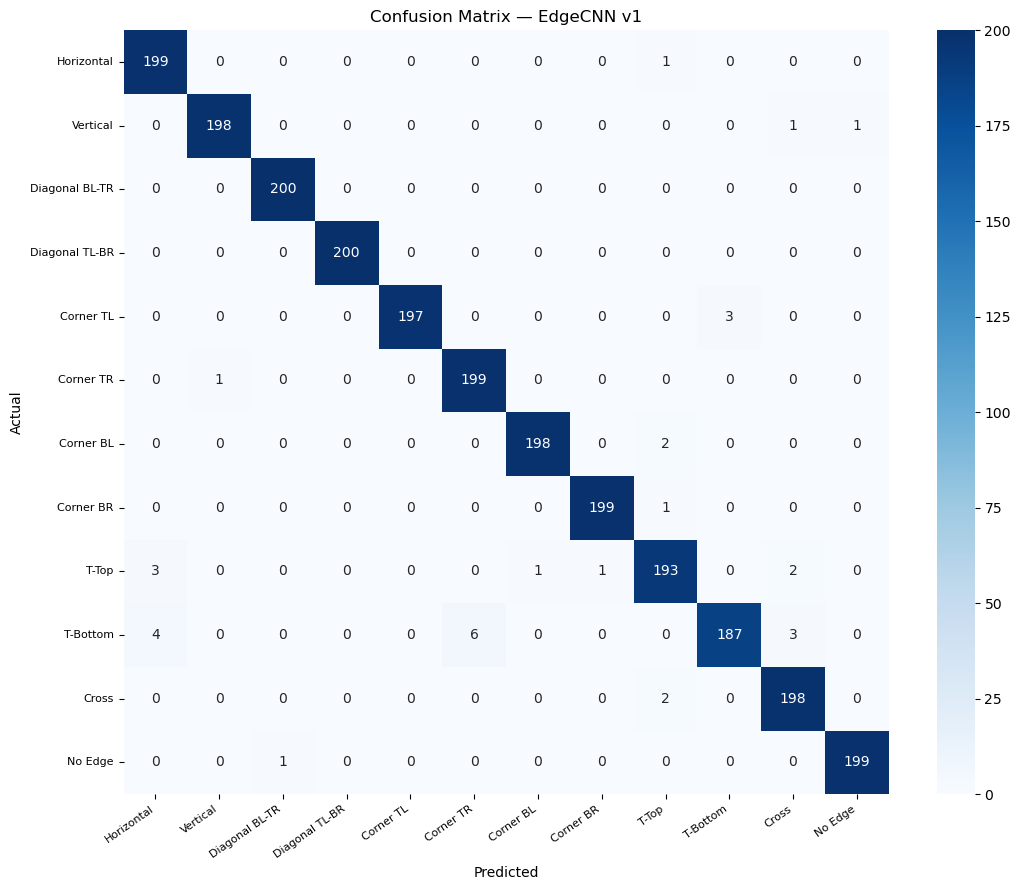

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(EDGE_TYPES.values()),
            yticklabels=list(EDGE_TYPES.values()), ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — EdgeCNN v1')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('images/confusion_matrix_v1.png', dpi=120)
plt.show()

In [13]:
model.save('models/edge_cnn_v1_final.keras')
np.save('X_test_synthetic.npy', x_test)
np.save('y_test_synthetic.npy', y_test)

print('Saved: models/edge_cnn_v1_final.keras')
print('Saved: X_test_synthetic.npy, y_test_synthetic.npy')
print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')
print('\n→ Next: Run Notebook 3 (Training_Natural.ipynb)')

Saved: models/edge_cnn_v1_final.keras
Saved: X_test_synthetic.npy, y_test_synthetic.npy

Final Test Accuracy: 98.62%

→ Next: Run Notebook 3 (Training_Natural.ipynb)
